In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────────────────────
import os
import sympy as smp
import numpy as np
import matplotlib.pyplot as plt
from sympy import simplify, factor, cancel
from scipy.special import jv, kv, hankel1

from continuum_mechanics import vector
from continuum_mechanics import solids

from wave_plotter import plot_scalar_field, plot_field_grid, enable_latex_style
from extra_fns import latex_print, grad, lap_vec, rotation, complete_strain_stress_ccst, classical_limit_coeff

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SYMBOLIC SETUP
# ─────────────────────────────────────────────────────────────────────────────
t = smp.symbols('t')
r, th, z = smp.symbols('r, theta, z')
n = smp.symbols('n', integer=True)

a, rho, mu, lam_lame, eta, ell = smp.symbols('a, \\rho, \\mu, \\lambda, \\eta, \\ell', positive=True)
k, u0, omega, beta1, beta2     = smp.symbols('k_S, u_0, \\omega, \\beta_1, \\beta_2', real=True)
Bn, Cn                         = smp.symbols('B_n, C_n')

vareps = smp.Function('\\varepsilon')(n)
i      = smp.I

u_r  = smp.Function('u_r')(r, th, z)
u_th = smp.Function('u_{\\theta}')(r, th, z)
u_z  = smp.Function('u_z')(r, th, z)

u   = smp.Matrix([u_r, u_th, u_z])
cyl = (r, th, z)
h   = (1, r, 1)

display(u)

Matrix([
[       u_r(r, theta, z)],
[u_{\theta}(r, theta, z)],
[       u_z(r, theta, z)]])

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# KINEMATICS AND STRESSES  (run once for inspection)
# ─────────────────────────────────────────────────────────────────────────────
e_ten, curv_ten          = solids.disp_def_cst(u, cyl, h)
w_vec, w_ten             = rotation(u, cyl, h)
sigma_ten, *_, mu_ten    = complete_strain_stress_ccst(e_ten, curv_ten, w_ten, cyl, h, (lam_lame, mu, eta))

antiplane = {u_r: 0, u_th: 0, smp.diff(u_z, z): 0}
u_antiplane = u.subs(antiplane)
sigma_antiplane = simplify(sigma_ten.subs(antiplane).doit())
w_antiplane     = w_vec.subs(antiplane).doit()
mu_antiplane    = simplify(mu_ten.subs(antiplane).doit())

display(u_antiplane)
display(mu_antiplane)
latex_print(mu_antiplane[0,1])

Matrix([
[               0],
[               0],
[u_z(r, theta, z)]])

Matrix([
[                                                                                                                                     0, 2*\eta*(r*(r*Derivative(u_z(r, theta, z), (r, 2)) + Derivative(u_z(r, theta, z), r)) + Derivative(u_z(r, theta, z), (theta, 2)))/r**2, 0],
[-2*\eta*(r*(r*Derivative(u_z(r, theta, z), (r, 2)) + Derivative(u_z(r, theta, z), r)) + Derivative(u_z(r, theta, z), (theta, 2)))/r**2,                                                                                                                                     0, 0],
[                                                                                                                                     0,                                                                                                                                     0, 0]])

\frac{2 \eta \left(r \left(r \frac{\partial^{2}}{\partial r^{2}} u_{z}{\left(r,\theta,z \right)} + \frac{\partial}{\partial r} u_{z}{\left(r,\theta,z \right)}\right) + \frac{\partial^{2}}{\partial \theta^{2}} u_{z}{\left(r,\theta,z \right)}\right)}{r^{2}}


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# BOUNDARY CONDITIONS AND SOLUTION
# ─────────────────────────────────────────────────────────────────────────────
u_z_sln = (
    u0 * vareps * i**n * smp.besselj(n, k*r)
    + Bn * smp.besselk(n, beta1*r)
    + Cn * smp.hankel1(n, beta2*r)
) * smp.cos(n*th)

sln_subs = {smp.Function('u_z')(r, th, z): u_z_sln}
display(u_z_sln)

# extract the boundary conditions as equations
# only the first condition on w is used because of independency from the one of u
bdc_1 = smp.Eq(u_antiplane[2], 0)
display(bdc_1)

bdc_2 = smp.Eq(w_antiplane[1], 0)
display(bdc_2)

(I**n*u_0*\varepsilon(n)*besselj(n, k_S*r) + B_n*besselk(n, \beta_1*r) + C_n*hankel1(n, \beta_2*r))*cos(n*theta)

Eq(u_z(r, theta, z), 0)

Eq(-Derivative(u_z(r, theta, z), r)/2, 0)

In [5]:
# apply the boundary conditions at r = a
bdc_1_subs = bdc_1.subs(sln_subs).doit().subs({r: a})
bdc_2_subs = bdc_2.subs(sln_subs).doit().subs({r: a})

display(bdc_1_subs)
display(bdc_2_subs)

Eq((I**n*u_0*\varepsilon(n)*besselj(n, a*k_S) + B_n*besselk(n, \beta_1*a) + C_n*hankel1(n, \beta_2*a))*cos(n*theta), 0)

Eq(-(I**n*k_S*u_0*(besselj(n - 1, a*k_S)/2 - besselj(n + 1, a*k_S)/2)*\varepsilon(n) + B_n*\beta_1*(-besselk(n - 1, \beta_1*a)/2 - besselk(n + 1, \beta_1*a)/2) + C_n*\beta_2*(hankel1(n - 1, \beta_2*a)/2 - hankel1(n + 1, \beta_2*a)/2))*cos(n*theta)/2, 0)

In [6]:
# we simplify the expressions
bdc_1_pretty = smp.Eq(bdc_1_subs.lhs / smp.cos(n*th), 0)
bdc_2_pretty = smp.Eq(simplify(bdc_2_subs.lhs) * (-4) / smp.cos(n*th), 0)

display(bdc_1_pretty)
display(bdc_2_pretty)

Eq(I**n*u_0*\varepsilon(n)*besselj(n, a*k_S) + B_n*besselk(n, \beta_1*a) + C_n*hankel1(n, \beta_2*a), 0)

Eq(I**n*k_S*u_0*(besselj(n - 1, a*k_S) - besselj(n + 1, a*k_S))*\varepsilon(n) - B_n*\beta_1*(besselk(n - 1, \beta_1*a) + besselk(n + 1, \beta_1*a)) + C_n*\beta_2*(hankel1(n - 1, \beta_2*a) - hankel1(n + 1, \beta_2*a)), 0)

In [7]:
A_mat, b_vec = smp.linear_eq_to_matrix([bdc_1_pretty, bdc_2_pretty], [Bn, Cn])
sln          = A_mat.LUsolve(b_vec)

Bn_sln = simplify(cancel(sln[0]))
Cn_sln = simplify(cancel(sln[1]))

display(Bn_sln)
display(Cn_sln)

I**n*u_0*(-\beta_2*a*besselj(n, a*k_S)*hankel1(n - 1, \beta_2*a) + \beta_2*a*besselj(n, a*k_S)*hankel1(n + 1, \beta_2*a) - 2*a*k_S*besselj(n + 1, a*k_S)*hankel1(n, \beta_2*a) + 2*n*besselj(n, a*k_S)*hankel1(n, \beta_2*a))*\varepsilon(n)/(a*(\beta_1*besselk(n - 1, \beta_1*a)*hankel1(n, \beta_2*a) + \beta_1*besselk(n + 1, \beta_1*a)*hankel1(n, \beta_2*a) + \beta_2*besselk(n, \beta_1*a)*hankel1(n - 1, \beta_2*a) - \beta_2*besselk(n, \beta_1*a)*hankel1(n + 1, \beta_2*a)))

-I**n*u_0*(\beta_1*a*besselj(n, a*k_S)*besselk(n - 1, \beta_1*a) + \beta_1*a*besselj(n, a*k_S)*besselk(n + 1, \beta_1*a) - 2*a*k_S*besselj(n + 1, a*k_S)*besselk(n, \beta_1*a) + 2*n*besselj(n, a*k_S)*besselk(n, \beta_1*a))*\varepsilon(n)/(a*(\beta_1*besselk(n - 1, \beta_1*a)*hankel1(n, \beta_2*a) + \beta_1*besselk(n + 1, \beta_1*a)*hankel1(n, \beta_2*a) + \beta_2*besselk(n, \beta_1*a)*hankel1(n - 1, \beta_2*a) - \beta_2*besselk(n, \beta_1*a)*hankel1(n + 1, \beta_2*a)))

In [8]:
# we use the determinant of the matrix for aesthetics:
Delta = smp.symbols('\\Delta_n')

Bn_sln_det = Bn_sln.subs(smp.det(A_mat), Delta)
display(Bn_sln_det)

Cn_sln_det = Cn_sln.subs(smp.det(A_mat), Delta)
display(Cn_sln_det)

I**n*u_0*(-\beta_2*a*besselj(n, a*k_S)*hankel1(n - 1, \beta_2*a) + \beta_2*a*besselj(n, a*k_S)*hankel1(n + 1, \beta_2*a) - 2*a*k_S*besselj(n + 1, a*k_S)*hankel1(n, \beta_2*a) + 2*n*besselj(n, a*k_S)*hankel1(n, \beta_2*a))*\varepsilon(n)/(\Delta_n*a)

-I**n*u_0*(\beta_1*a*besselj(n, a*k_S)*besselk(n - 1, \beta_1*a) + \beta_1*a*besselj(n, a*k_S)*besselk(n + 1, \beta_1*a) - 2*a*k_S*besselj(n + 1, a*k_S)*besselk(n, \beta_1*a) + 2*n*besselj(n, a*k_S)*besselk(n, \beta_1*a))*\varepsilon(n)/(\Delta_n*a)

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CLASSICAL LIMIT  (verification)
# ─────────────────────────────────────────────────────────────────────────────
Bn_classical = classical_limit_coeff(Bn_sln, beta1, beta2, k, n, a)
Cn_classical = classical_limit_coeff(Cn_sln, beta1, beta2, k, n, a)

display(Bn_classical)   # → 0
display(Cn_classical)   # → -i^n * w0 * eps(n) * J_n(k*a) / H_n^(1)(k*a)


0

-I**n*u_0*\varepsilon(n)*besselj(n, a*k_S)/hankel1(n, a*k_S)

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# ADIMENSIONALIZATION  (khat = k_S * a, lhat = ell / a, a = 1)
# ─────────────────────────────────────────────────────────────────────────────
khat, lhat = smp.symbols('\\hat{k}_S, \\hat{\\ell}')

# step 1: substitute beta1 and beta2 definitions
beta1_subs = {beta1: smp.sqrt((1 + smp.sqrt(1 + 4*ell**2 * k**2)) / (2*ell**2))}
beta2_subs = {beta2: smp.sqrt(-(1 - smp.sqrt(1 + 4*ell**2 * k**2)) / (2*ell**2))}

Bn_with_no_betas = Bn_sln.subs(beta1_subs).subs(beta2_subs)
Cn_with_no_betas = Cn_sln.subs(beta1_subs).subs(beta2_subs)

# step 2: substitute k=khat, ell=lhat, w0=1 — in separate steps to avoid parallel subs
subs_num = {k: khat/a, ell: lhat*a, u0: 1}

Bn_ad = factor(Bn_with_no_betas.subs(subs_num).subs(
    vareps, smp.Piecewise((1, smp.Eq(n, 0)), (2, True))))
Cn_ad = factor(Cn_with_no_betas.subs(subs_num).subs(
    vareps, smp.Piecewise((1, smp.Eq(n, 0)), (2, True))))

print("Free symbols Bn:", Bn_ad.free_symbols)  # → {n, khat, lhat}
print("Free symbols Cn:", Cn_ad.free_symbols)  # → {n, khat, lhat}

Bn_func = smp.lambdify((n, khat, lhat), Bn_ad,
    modules=[{"besselj": jv, "besselk": kv, "hankel1": hankel1}, "numpy"])
Cn_func = smp.lambdify((n, khat, lhat), Cn_ad,
    modules=[{"besselj": jv, "besselk": kv, "hankel1": hankel1}, "numpy"])

Free symbols Bn: {\hat{\ell}, \hat{k}_S, n}
Free symbols Cn: {\hat{\ell}, \hat{k}_S, n}


In [11]:
def w_field(R_hat, TH, khat_val, lhat_val, Nmax):
    """
    compute total SH field. nan_to_num is applied to the FULL n-th term
    (J_n + Bn*K_n + Cn*H_n)*cos(nθ) — not just the coefficients.
    this correctly handles the case where Bn overflows at large n,
    because the full term is physically negligible (series has converged).
    """
    import numpy as np
    from scipy.special import jv, kv, hankel1

    def beta1_val(kh, lh):
        return np.sqrt((1 + np.sqrt(1 + 4*lh**2*kh**2)) / (2*lh**2))

    def beta2_val(kh, lh):
        return np.sqrt(-(1 - np.sqrt(1 + 4*lh**2*kh**2)) / (2*lh**2))

    b1 = beta1_val(khat_val, lhat_val)
    b2 = beta2_val(khat_val, lhat_val)

    total = np.zeros_like(R_hat, dtype=complex)
    eps_n = lambda n_val: 1 if n_val == 0 else 2

    for n_val in range(Nmax + 1):
        try:
            Bn_val = Bn_func(n_val, khat_val, lhat_val)
            Cn_val = Cn_func(n_val, khat_val, lhat_val)

            term = (
                eps_n(n_val) * (1j)**n_val * jv(n_val, khat_val * R_hat)
                + Bn_val * kv(n_val, b1 * R_hat)
                + Cn_val * hankel1(n_val, b2 * R_hat)
            ) * np.cos(n_val * TH)

            cleaned = np.nan_to_num(term, nan=0.0, posinf=0.0, neginf=0.0)

            if np.any(~np.isfinite(term)):
                print(f"  [nan_to_num applied] n={n_val}")

            total += cleaned

        except Exception as e:
            print(f"  [exception] n={n_val}: {e}")
            continue

    return total

In [12]:
khat_vals = [0.8, 2.0, 5.0]
lhat_vals = [0.01, 0.1, 1.0]
Nmax      = 100

resolution = 250
L = 12
x = np.linspace(-L, L, resolution)
y = np.linspace(-L, L, resolution)
X, Y = np.meshgrid(x, y)
R_hat = np.sqrt(X**2 + Y**2)
TH    = np.arctan2(Y, X)
mask  = R_hat < 1.0

Z_list_real  = []
Z_list_mag   = []
Z_list_phase = []

for kv_ in khat_vals:
    for lv_ in lhat_vals:
        print(f"\nComputing khat={kv_}, lhat={lv_}...")
        W = w_field(R_hat, TH, kv_, lv_, Nmax)
        Z_list_real.append(np.ma.array(np.real(W),  mask=mask))
        Z_list_mag.append(np.ma.array(np.abs(W),   mask=mask))
        Z_list_phase.append(np.ma.array(np.angle(W), mask=mask))


Computing khat=0.8, lhat=0.01...
  [nan_to_num applied] n=98
  [nan_to_num applied] n=99
  [nan_to_num applied] n=100

Computing khat=0.8, lhat=0.1...
  [nan_to_num applied] n=98
  [nan_to_num applied] n=99
  [nan_to_num applied] n=100

Computing khat=0.8, lhat=1.0...


<lambdifygenerated-1>:2: RuntimeWarning: overflow encountered in scalar multiply
  return (1/2)*sqrt(2)*1j**n*(-4*Dummy_396*Dummy_397*besselj(n + 1, Dummy_396)*hankel1(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) + 4*Dummy_397*n*besselj(n, Dummy_396)*hankel1(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) - sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)*besselj(n, Dummy_396)*hankel1(n - 1, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) + sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)*besselj(n, Dummy_396)*hankel1(n + 1, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397))*select([equal(n, 0),True], [1,2], default=nan)/(sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)*besselk(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) + 1)/Dummy_397)*hankel1(n - 1, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) - sqrt(sqrt(4*Dummy_396**2*Du

  [nan_to_num applied] n=84


<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in scalar subtract
  return (1/2)*sqrt(2)*1j**n*(-4*Dummy_396*Dummy_397*besselj(n + 1, Dummy_396)*hankel1(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) + 4*Dummy_397*n*besselj(n, Dummy_396)*hankel1(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) - sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)*besselj(n, Dummy_396)*hankel1(n - 1, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) + sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)*besselj(n, Dummy_396)*hankel1(n + 1, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397))*select([equal(n, 0),True], [1,2], default=nan)/(sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)*besselk(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) + 1)/Dummy_397)*hankel1(n - 1, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) - sqrt(sqrt(4*Dummy_396*

  [nan_to_num applied] n=85
  [nan_to_num applied] n=86
  [nan_to_num applied] n=87
  [nan_to_num applied] n=88
  [nan_to_num applied] n=89
  [nan_to_num applied] n=90
  [nan_to_num applied] n=91
  [nan_to_num applied] n=92
  [nan_to_num applied] n=93
  [nan_to_num applied] n=94
  [nan_to_num applied] n=95
  [nan_to_num applied] n=96
  [nan_to_num applied] n=97
  [nan_to_num applied] n=98
  [nan_to_num applied] n=99
  [nan_to_num applied] n=100

Computing khat=2.0, lhat=0.01...

Computing khat=2.0, lhat=0.1...

Computing khat=2.0, lhat=1.0...
  [nan_to_num applied] n=92
  [nan_to_num applied] n=93
  [nan_to_num applied] n=94
  [nan_to_num applied] n=95
  [nan_to_num applied] n=96
  [nan_to_num applied] n=97
  [nan_to_num applied] n=98
  [nan_to_num applied] n=99
  [nan_to_num applied] n=100

Computing khat=5.0, lhat=0.01...

Computing khat=5.0, lhat=0.1...

Computing khat=5.0, lhat=1.0...


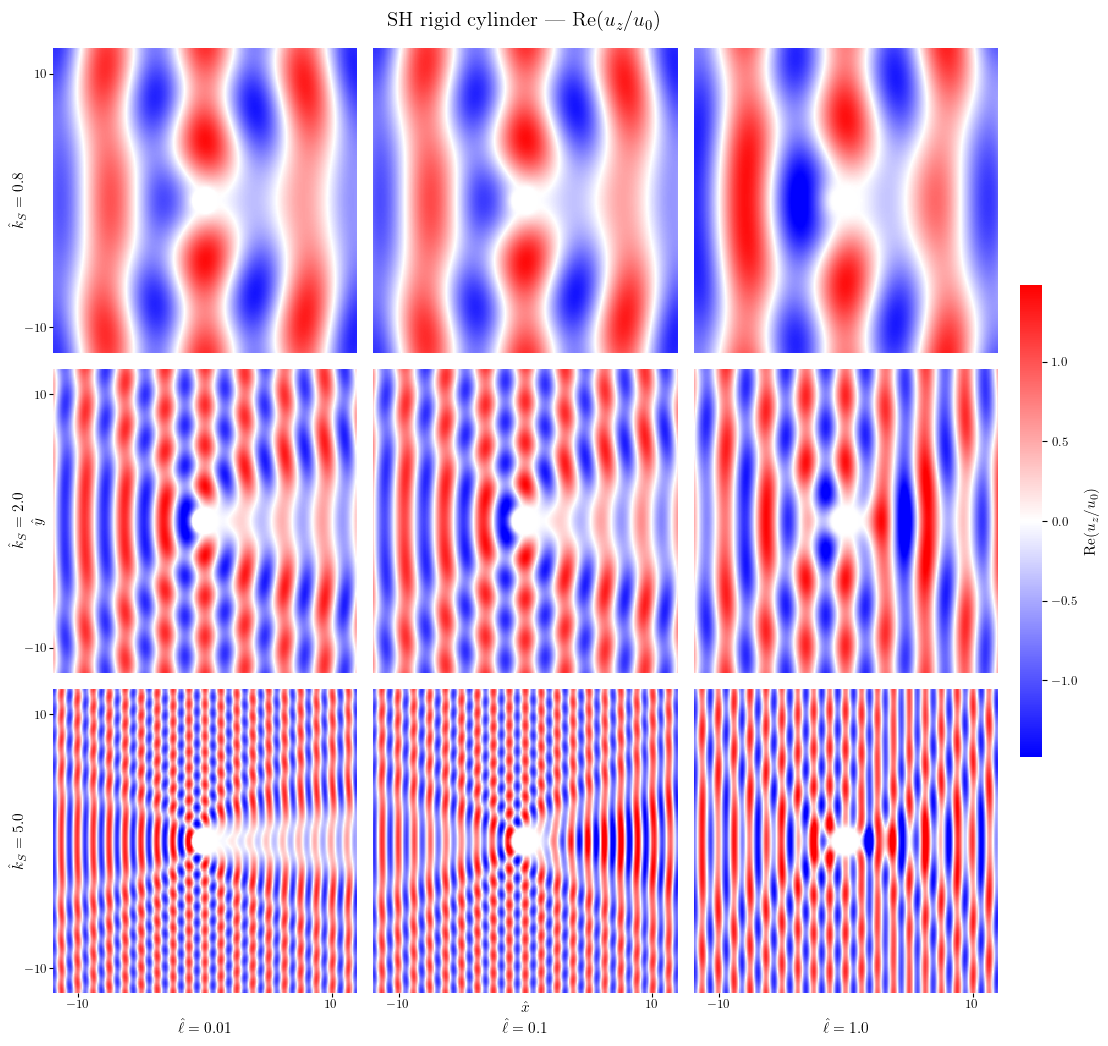

In [13]:
# ── parte real ────────────────────────────────────────────────────────────────
enable_latex_style()

plot_field_grid(
    X, Y, Z_list_real,
    cmap="bwr",
    xlabel=r"$\hat{x}$", ylabel=r"$\hat{y}$",
    cbar_label=r"$\mathrm{Re}(u_z/u_0)$",
    suptitle=r"SH rigid cylinder — $\mathrm{Re}(u_z/u_0)$",
    row_labels=[rf"$\hat{{k}}_S = {kv_}$" for kv_ in khat_vals],
    col_labels=[rf"$\hat{{\ell}} = {lv_}$" for lv_ in lhat_vals],
    center_zero=True, symmetric_limits=True,
    vmax_percentile=99.5,
    filename="SH_R_real_grid", save_folder="figs", show=True
)

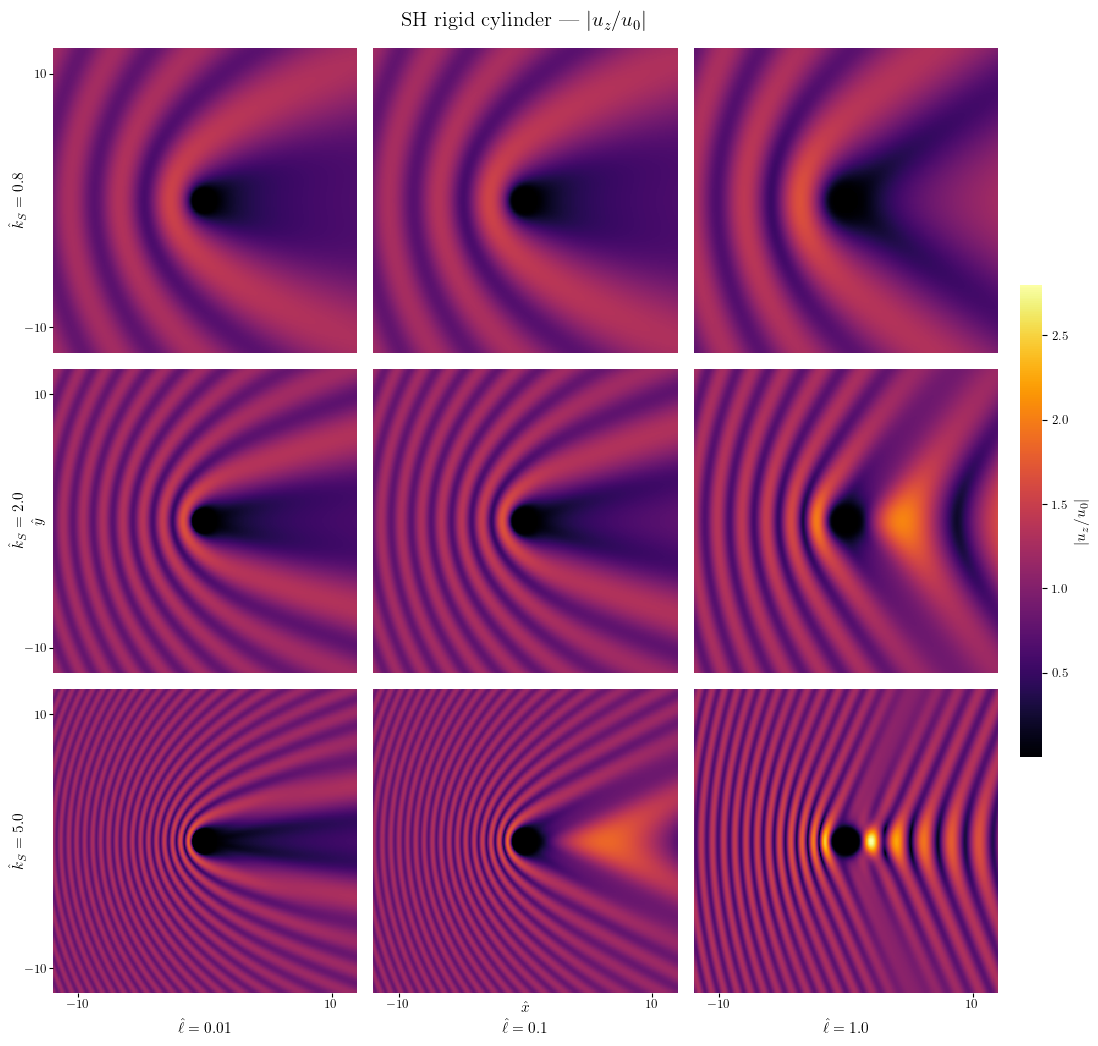

In [14]:
import copy
inferno_black = copy.copy(plt.cm.inferno)
inferno_black.set_bad('black')

plot_field_grid(
    X, Y, Z_list_mag,
    cmap=inferno_black,
    xlabel=r"$\hat{x}$", ylabel=r"$\hat{y}$",
    cbar_label=r"$|u_z/u_0|$",
    suptitle=r"SH rigid cylinder — $|u_z/u_0|$",
    row_labels=[rf"$\hat{{k}}_S = {kv_}$" for kv_ in khat_vals],
    col_labels=[rf"$\hat{{\ell}} = {lv_}$" for lv_ in lhat_vals],
    center_zero=False, symmetric_limits=False,
    filename="SH_R_mag_grid", save_folder="figs", show=True
)

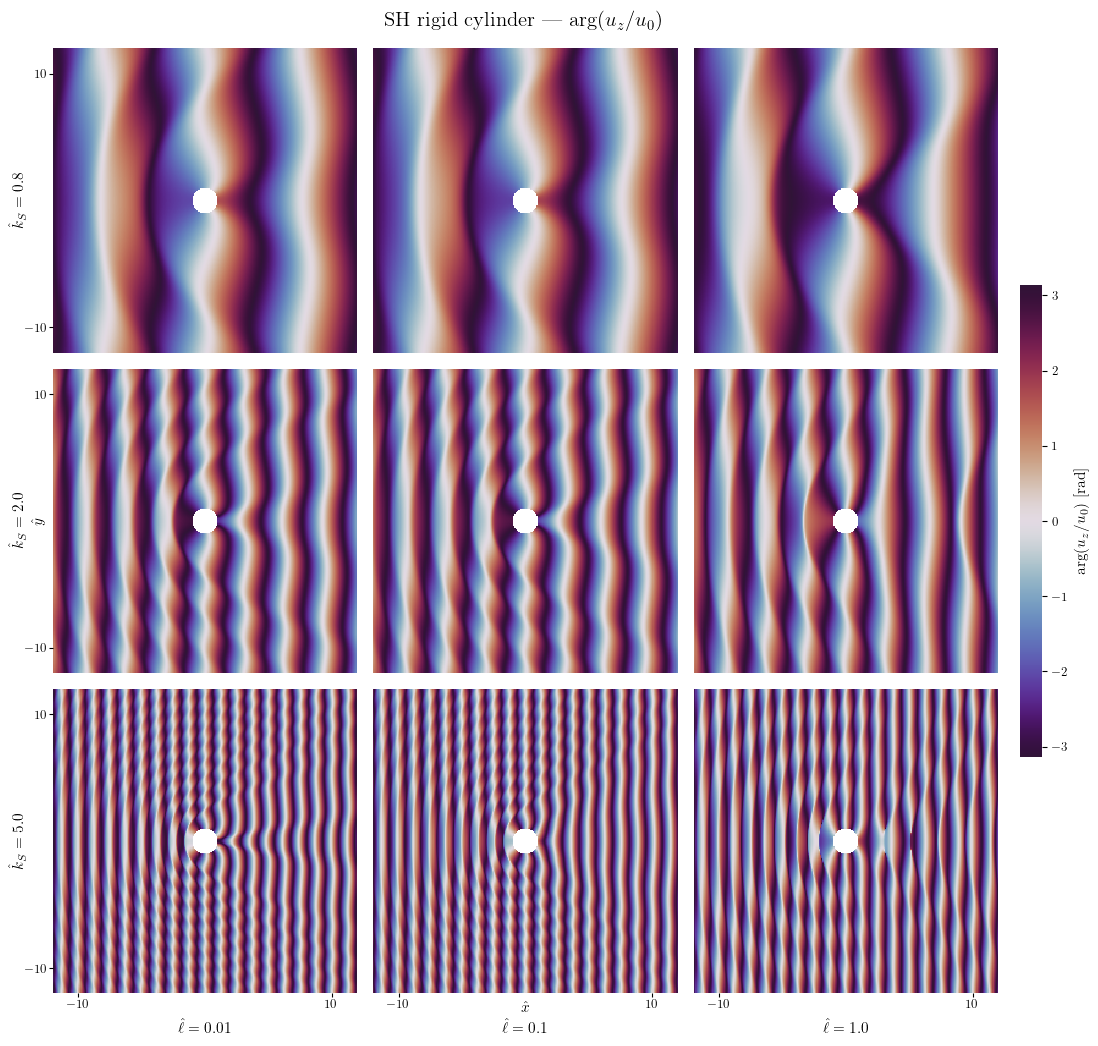

In [15]:
plot_field_grid(
    X, Y, Z_list_phase,
    cmap="twilight_shifted",
    xlabel=r"$\hat{x}$", ylabel=r"$\hat{y}$",
    cbar_label=r"$\arg(u_z/u_0)$ [rad]",
    suptitle=r"SH rigid cylinder — $\arg(u_z/u_0)$",
    row_labels=[rf"$\hat{{k}}_S = {kv_}$" for kv_ in khat_vals],
    col_labels=[rf"$\hat{{\ell}} = {lv_}$" for lv_ in lhat_vals],
    center_zero=False, symmetric_limits=False,
    filename="SH_R_phase_grid", save_folder="figs", show=True
)

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# SH RIGID CYLINDER — BOUNDARY STRESSES AND DSCF
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs("figs", exist_ok=True)
enable_latex_style()

_bessel_mods = [{"besselj": jv, "besselk": kv, "hankel1": hankel1}, "numpy"]

def set_angle_ticks_pi(ax):
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax.set_xticklabels([
        r"$0$", r"$\pi/2$", r"$\pi$",
        r"$3\pi/2$", r"$2\pi$"
    ])


def nice_radial_ticks_one_decimal(rmax):
    rmax = np.ceil(rmax * 10) / 10
    return [rmax/3, 2*rmax/3, rmax]

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# BOUNDARY FUNCTION BUILDER
# ─────────────────────────────────────────────────────────────────────────────

def _adim_boundary_expr_SH_rigid(expr):
    expr_b = expr.subs(sln_subs).doit()
    expr_b = expr_b.subs({r: a})

    expr_b = expr_b.subs({eta: mu * ell**2})

    expr_b = expr_b.subs({
        beta1: smp.sqrt((1 + smp.sqrt(1 + 4*ell**2*k**2)) / (2*ell**2)),
        beta2: smp.sqrt(-(1 - smp.sqrt(1 + 4*ell**2*k**2)) / (2*ell**2)),
    })

    expr_b = expr_b.subs({
        k: khat/a,
        ell: lhat*a,
        u0: 1,
    })

    expr_b = expr_b.subs(
        vareps,
        smp.Piecewise((1, smp.Eq(n, 0)), (2, True))
    )

    expr_b = expr_b.subs({mu: 1, a: 1})

    return simplify(expr_b)


def make_boundary_func_SH_rigid(expr, name):
    print(f"Building boundary function: {name}")

    expr_ad = _adim_boundary_expr_SH_rigid(expr)

    func = smp.lambdify(
        (n, th, khat, lhat, Bn, Cn),
        expr_ad,
        modules=_bessel_mods
    )

    return func

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# RELEVANT BOUNDARY QUANTITIES
# ─────────────────────────────────────────────────────────────────────────────

uz_bnd_func = make_boundary_func_SH_rigid(u_antiplane[2], "u_z")
omega_theta_bnd_func = make_boundary_func_SH_rigid(w_antiplane[1], "omega_theta")

sig_rz_func = make_boundary_func_SH_rigid(sigma_antiplane[0, 2], "sigma_rz")
sig_tz_func = make_boundary_func_SH_rigid(sigma_antiplane[1, 2], "sigma_thetaz")

# ─────────────────────────────────────────────────────────────────────────────
# EXTRA — ALL SH STRESS COMPONENTS ALONG THE RIGID BOUNDARY
# ─────────────────────────────────────────────────────────────────────────────

# Build additional stress components
sig_zr_func = make_boundary_func_SH_rigid(sigma_antiplane[2, 0], "sigma_zr")
sig_zt_func = make_boundary_func_SH_rigid(sigma_antiplane[2, 1], "sigma_ztheta")

Building boundary function: u_z
Building boundary function: omega_theta
Building boundary function: sigma_rz
Building boundary function: sigma_thetaz
Building boundary function: sigma_zr
Building boundary function: sigma_ztheta


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# SERIES EVALUATION AT r = a
# ─────────────────────────────────────────────────────────────────────────────

def boundary_series_SH_rigid(func, theta, khat_val, lhat_val, Nmax=200):
    total = np.zeros_like(theta, dtype=complex)

    for n_val in range(Nmax + 1):
        Bn_val = Bn_func(n_val, khat_val, lhat_val)
        Cn_val = Cn_func(n_val, khat_val, lhat_val)

        term = func(
            n_val, theta,
            khat_val, lhat_val,
            Bn_val, Cn_val
        )

        term = np.nan_to_num(term, nan=0.0, posinf=0.0, neginf=0.0)
        total += term

    return total


def incident_boundary_series_SH_rigid(func, theta, khat_val, lhat_val, Nmax=200):
    total = np.zeros_like(theta, dtype=complex)

    for n_val in range(Nmax + 1):
        term = func(
            n_val, theta,
            khat_val, lhat_val,
            0.0, 0.0
        )

        term = np.nan_to_num(term, nan=0.0, posinf=0.0, neginf=0.0)
        total += term

    return total


def sigma0_incident_SH_rigid(theta, khat_val, lhat_val, Nmax=200):
    sig_inc = incident_boundary_series_SH_rigid(
        sig_tz_func, theta, khat_val, lhat_val, Nmax
    )
    return np.max(np.abs(sig_inc))

<lambdifygenerated-1>:2: RuntimeWarning: overflow encountered in scalar multiply
  return (1/2)*sqrt(2)*1j**n*(-4*Dummy_396*Dummy_397*besselj(n + 1, Dummy_396)*hankel1(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) + 4*Dummy_397*n*besselj(n, Dummy_396)*hankel1(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) - sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)*besselj(n, Dummy_396)*hankel1(n - 1, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) + sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)*besselj(n, Dummy_396)*hankel1(n + 1, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397))*select([equal(n, 0),True], [1,2], default=nan)/(sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)*besselk(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) + 1)/Dummy_397)*hankel1(n - 1, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) - sqrt(sqrt(4*Dummy_396**2*Du

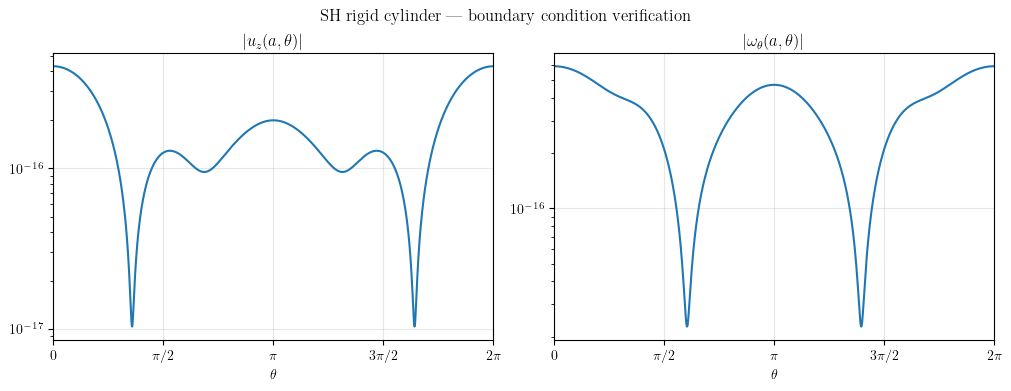

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 0 — BOUNDARY CONDITION VERIFICATION
# BCs: u_z = 0, omega_theta = 0
# ─────────────────────────────────────────────────────────────────────────────

theta = np.linspace(0, 2*np.pi, 1200)

khat_val = 2.0
lhat_val = 0.1
Nmax_bnd = 200

uz_b = boundary_series_SH_rigid(
    uz_bnd_func, theta, khat_val, lhat_val, Nmax_bnd
)

om_b = boundary_series_SH_rigid(
    omega_theta_bnd_func, theta, khat_val, lhat_val, Nmax_bnd
)

fig, axs = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)

axs[0].semilogy(theta, np.abs(uz_b))
axs[0].set_title(r"$|u_z(a,\theta)|$")

axs[1].semilogy(theta, np.abs(om_b))
axs[1].set_title(r"$|\omega_\theta(a,\theta)|$")

for ax in axs:
    ax.set_xlabel(r"$\theta$")
    ax.set_xlim(0, 2*np.pi)
    set_angle_ticks_pi(ax)
    ax.grid(True, alpha=0.3)

fig.suptitle(r"SH rigid cylinder — boundary condition verification")
plt.savefig("figs/SH_R_BC_verification.png", dpi=300)
plt.show()

<lambdifygenerated-1>:2: RuntimeWarning: overflow encountered in scalar multiply
  return (1/2)*sqrt(2)*1j**n*(-4*Dummy_396*Dummy_397*besselj(n + 1, Dummy_396)*hankel1(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) + 4*Dummy_397*n*besselj(n, Dummy_396)*hankel1(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) - sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)*besselj(n, Dummy_396)*hankel1(n - 1, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) + sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)*besselj(n, Dummy_396)*hankel1(n + 1, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397))*select([equal(n, 0),True], [1,2], default=nan)/(sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)*besselk(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) + 1)/Dummy_397)*hankel1(n - 1, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) - sqrt(sqrt(4*Dummy_396**2*Du

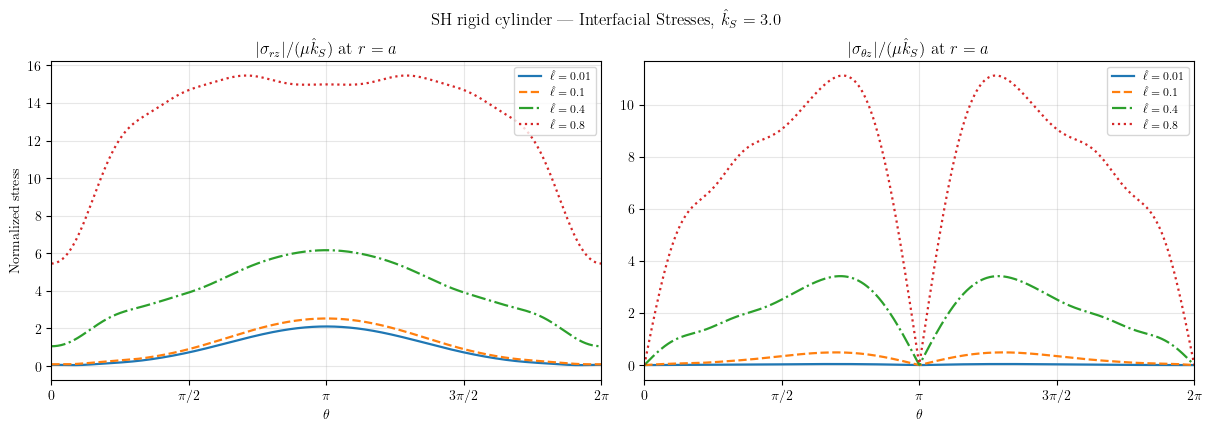

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1 — BOUNDARY REACTIONS
# Normalization: mu * khat_S
# ─────────────────────────────────────────────────────────────────────────────

theta = np.linspace(0, 2*np.pi, 1200)

khat_val = 3.0
lhat_vals = [0.01, 0.1, 0.4, 0.8]
linestyles = ["-", "--", "-.", ":"]
Nmax_bnd = 200

fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

for lhat_val, ls in zip(lhat_vals, linestyles):

    sig_rz = boundary_series_SH_rigid(
        sig_rz_func, theta, khat_val, lhat_val, Nmax_bnd
    )

    sig_tz = boundary_series_SH_rigid(
        sig_tz_func, theta, khat_val, lhat_val, Nmax_bnd
    )

    axs[0].plot(
        theta,
        np.abs(sig_rz) / khat_val,
        linestyle=ls,
        linewidth=1.6,
        label=rf"$\hat{{\ell}}={lhat_val}$"
    )

    axs[1].plot(
        theta,
        np.abs(sig_tz) / khat_val,
        linestyle=ls,
        linewidth=1.6,
        label=rf"$\hat{{\ell}}={lhat_val}$"
    )

axs[0].set_title(r"$|\sigma_{rz}|/(\mu \hat{k}_S)$ at $r=a$")
axs[1].set_title(r"$|\sigma_{\theta z}|/(\mu \hat{k}_S)$ at $r=a$")
axs[0].set_ylabel("Normalized stress")

for ax in axs:
    ax.set_xlabel(r"$\theta$")
    ax.set_xlim(0, 2*np.pi)
    set_angle_ticks_pi(ax)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle(rf"SH rigid cylinder — Interfacial Stresses, $\hat{{k}}_S={khat_val}$")
plt.savefig("figs/SH_R_boundary_reactions.png", dpi=300)
plt.show()

<lambdifygenerated-1>:2: RuntimeWarning: overflow encountered in scalar multiply
  return (1/2)*sqrt(2)*1j**n*(-4*Dummy_396*Dummy_397*besselj(n + 1, Dummy_396)*hankel1(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) + 4*Dummy_397*n*besselj(n, Dummy_396)*hankel1(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) - sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)*besselj(n, Dummy_396)*hankel1(n - 1, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) + sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)*besselj(n, Dummy_396)*hankel1(n + 1, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397))*select([equal(n, 0),True], [1,2], default=nan)/(sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)*besselk(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) + 1)/Dummy_397)*hankel1(n - 1, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) - sqrt(sqrt(4*Dummy_396**2*Du

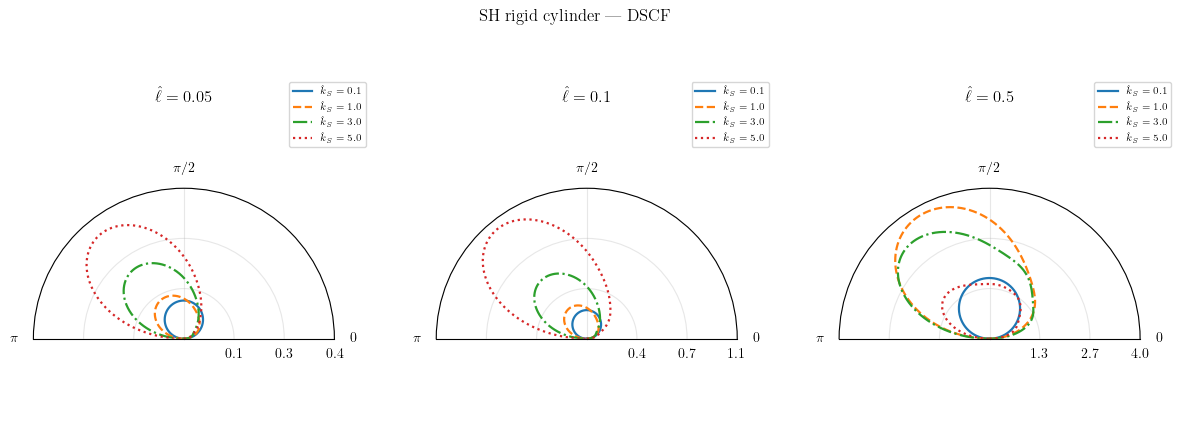

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 3 — DSCF POLAR HALF-PLOT
# theta in [0, pi]
# ─────────────────────────────────────────────────────────────────────────────

theta = np.linspace(0, np.pi, 1000)

lhat_vals = [0.05, 0.1, 0.5]
khat_vals = [0.1, 1.0, 3.0, 5.0]
linestyles = ["-", "--", "-.", ":"]

Nmax_bnd = 200

fig, axs = plt.subplots(
    1, 3,
    figsize=(12.0, 4.3),
    subplot_kw={"projection": "polar"},
    constrained_layout=False
)

for ax, lhat_val in zip(axs, lhat_vals):

    for khat_val, ls in zip(khat_vals, linestyles):

        sig_tz = boundary_series_SH_rigid(
            sig_tz_func,
            theta,
            khat_val,
            lhat_val,
            Nmax_bnd
        )

        sigma0 = sigma0_incident_SH_rigid(
            theta,
            khat_val,
            lhat_val,
            Nmax_bnd
        )

        Sd = np.abs(sig_tz) / sigma0

        ax.plot(
            theta, Sd,
            linestyle=ls,
            linewidth=1.6,
            label=rf"$\hat{{k}}_S={khat_val}$"
        )

    rmax = ax.get_rmax()
    rticks = nice_radial_ticks_one_decimal(rmax)

    ax.set_rmax(rticks[-1])
    ax.set_rticks(rticks)
    ax.set_yticklabels([f"{tick:.1f}" for tick in rticks])

    ax.set_title(rf"$\hat{{\ell}}={lhat_val}$", pad=8)

    ax.set_thetamin(0)
    ax.set_thetamax(180)
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)

    ax.set_xticks([0, np.pi/2, np.pi])
    ax.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$"])

    ax.grid(True, alpha=0.3)

    ax.legend(
        fontsize=7,
        loc="upper right",
        bbox_to_anchor=(1.12, 1.12),
        frameon=True
    )

fig.suptitle(
    r"SH rigid cylinder — DSCF",
    y=1.02
)

fig.subplots_adjust(
    left=0.04,
    right=0.98,
    bottom=0.08,
    top=0.78,
    wspace=0.25
)

plt.savefig("figs/SH_R_DSCF_polar_half.png", dpi=300)
plt.show()

<lambdifygenerated-1>:2: RuntimeWarning: overflow encountered in scalar multiply
  return (1/2)*sqrt(2)*1j**n*(-4*Dummy_396*Dummy_397*besselj(n + 1, Dummy_396)*hankel1(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) + 4*Dummy_397*n*besselj(n, Dummy_396)*hankel1(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) - sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)*besselj(n, Dummy_396)*hankel1(n - 1, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) + sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)*besselj(n, Dummy_396)*hankel1(n + 1, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397))*select([equal(n, 0),True], [1,2], default=nan)/(sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)*besselk(n, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) + 1)/Dummy_397)*hankel1(n - 1, (1/2)*sqrt(2)*sqrt(sqrt(4*Dummy_396**2*Dummy_397**2 + 1) - 1)/Dummy_397) - sqrt(sqrt(4*Dummy_396**2*Du

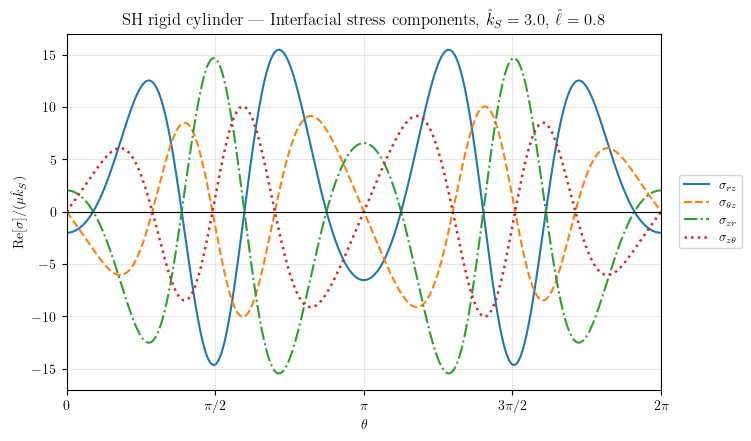

In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT — Re[stress] / (mu khat_S) along boundary
# ─────────────────────────────────────────────────────────────────────────────

theta = np.linspace(0, 2*np.pi, 1200)

khat_val = 3.0
lhat_val = 0.8
Nmax_bnd = 200

sig_rz = boundary_series_SH_rigid(sig_rz_func, theta, khat_val, lhat_val, Nmax_bnd)
sig_tz = boundary_series_SH_rigid(sig_tz_func, theta, khat_val, lhat_val, Nmax_bnd)
sig_zr = boundary_series_SH_rigid(sig_zr_func, theta, khat_val, lhat_val, Nmax_bnd)
sig_zt = boundary_series_SH_rigid(sig_zt_func, theta, khat_val, lhat_val, Nmax_bnd)

fig, ax = plt.subplots(figsize=(7.4, 4.3), constrained_layout=True)

ax.plot(
    theta, np.real(sig_rz) / khat_val,
    linestyle="-",
    linewidth=1.5,
    label=r"$\sigma_{rz}$"
)

ax.plot(
    theta, np.real(sig_tz) / khat_val,
    linestyle="--",
    linewidth=1.5,
    label=r"$\sigma_{\theta z}$"
)

ax.plot(
    theta, np.real(sig_zr) / khat_val,
    linestyle="-.",
    linewidth=1.5,
    label=r"$\sigma_{zr}$"
)

ax.plot(
    theta, np.real(sig_zt) / khat_val,
    linestyle=":",
    linewidth=1.8,
    label=r"$\sigma_{z\theta}$"
)

ax.axhline(0, color="black", linewidth=0.8)

ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\mathrm{Re}[\sigma]/(\mu \hat{k}_S)$")
ax.set_xlim(0, 2*np.pi)
set_angle_ticks_pi(ax)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))

ax.set_title(
    rf"SH rigid cylinder — Interfacial stress components, "
    rf"$\hat{{k}}_S={khat_val}$, $\hat{{\ell}}={lhat_val}$"
)

plt.savefig("figs/SH_R_all_boundary_stresses.png", dpi=300, bbox_inches="tight")
plt.show()